#DC-DSE Assignment 2025/26

---

**Student**: Mattia Di Luca \
**ID**: 5213177

## **P1**: Data Processing Problem

As Industry 4.0 drives the exponential growth of IIoT devices, it simultaneously introduces critical security risks. For example, in Smart Grids or car manufacturing, thousands of sensors interact to control critical systems; a compromise in this mesh could lead to catastrophic service disruptions or production halts.

This project aims to build a MLprocess to identify and classify malicious activity.

The dataset comprises granular network flows capturing both normal behavior and 14 types of complex attacks, including DDoS and SQL Injection. To handle the high dimensionality and massive volume of this network traffic, we utilize PySpark's distributed computing framework. This approach allows for efficient data ingestion and analysis, ultimately helping cybersecurity teams prioritize defenses against the most critical IoT threats.

In [ ]:
# @title Default Imports
# for Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, count, stddev, expr, isnan, approx_count_distinct, format_number, lit
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, IndexToString
from pyspark.ml.classification import LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

# for plots and help functions
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [ ]:
# @title Default Time Functions
def time_now():  # returns current time
    now = datetime.now()
    return now.strftime('%H:%M:%S.%f')

def calculate_elapsed_time(start_time: str, end_time: str, time_format: str = '%H:%M:%S.%f') -> str: # returns elapsed time in milliseconds between two time strings
    start_dt = datetime.strptime(start_time, time_format) # start time
    end_dt = datetime.strptime(end_time, time_format) # end time

    elapsed_time_ms = int((end_dt - start_dt).total_seconds() * 1000)
    return elapsed_time_ms

### Data Processing and Cleaning

In [ ]:
spark = SparkSession.builder \
    .appName("DC_Assignment") \
    .getOrCreate()

file_path = "/content/DNN-EdgeIIoT-dataset.csv"
df_raw = spark.read.csv(file_path, header=True, inferSchema=False)

For our purpose, are not necessary all the 63 columns in the next block We proceed to clean the data and exclude unnecessary columns.

In [ ]:
new_columns = [c.replace(".", "_").replace(" ", "") for c in df_raw.columns]
df_sanitized = df_raw.toDF(*new_columns)

selected_features = [
    "tcp_len",              # TCP Payload
    "http_content_length",  # HTTP Payload
    "mqtt_len",             # MQTT Payload
    "mbtcp_len",            # Modbus Payload
    "tcp_srcport",          # source port
    "udp_port",             # udp port
    "mqtt_topic_len",       # Lunghezza Topic IoT
    "tcp_ack",              # Flag tecnico
    "tcp_seq"               # Sequenza pacchetti
]
target_col = "Attack_type"

cols_to_keep = selected_features + [target_col]
existing_cols = [c for c in cols_to_keep if c in df_sanitized.columns]
df_reduced = df_sanitized.select(existing_cols)

for feature in selected_features:
    if feature in df_reduced.columns:
        df_reduced = df_reduced.withColumn(feature, expr(f"try_cast({feature} as double)"))

df_imputed = df_reduced.na.fill(0.0)

#adding computed column for further computation
df_clean = df_imputed \
    .withColumn("Unified_Payload",
                col("tcp_len") +
                col("http_content_length") +
                col("mqtt_len") +
                col("mbtcp_len")
    ) \
    .withColumn("Binary_Label",
                when(col(target_col) == "Normal", 0).otherwise(1)
    )

In [ ]:
df_clean.show(5)

+-------+-------------------+--------+---------+-----------+--------+--------------+-------+-------+-----------+---------------+------------+
|tcp_len|http_content_length|mqtt_len|mbtcp_len|tcp_srcport|udp_port|mqtt_topic_len|tcp_ack|tcp_seq|Attack_type|Unified_Payload|Binary_Label|
+-------+-------------------+--------+---------+-----------+--------+--------------+-------+-------+-----------+---------------+------------+
|    0.0|                0.0|     0.0|      0.0|     1883.0|     0.0|           0.0|    1.0|    0.0|     Normal|            0.0|           0|
|   14.0|                0.0|    12.0|      0.0|    64855.0|     0.0|           0.0|    1.0|    1.0|     Normal|           26.0|           0|
|    0.0|                0.0|     0.0|      0.0|     1883.0|     0.0|           0.0|   15.0|    1.0|     Normal|            0.0|           0|
|    4.0|                0.0|     2.0|      0.0|     1883.0|     0.0|           0.0|   15.0|    1.0|     Normal|            6.0|           0|
|   41

## **P2**: PySpark solutions

### 1: Data Distribution


After the sanitization, the first analytical task is to examine the overall health of the network. Grouped all traffic in two category: *Normal* and *Attack*. This high-level view is essential to determine distribution of the network and identify potential bias in the dataset.

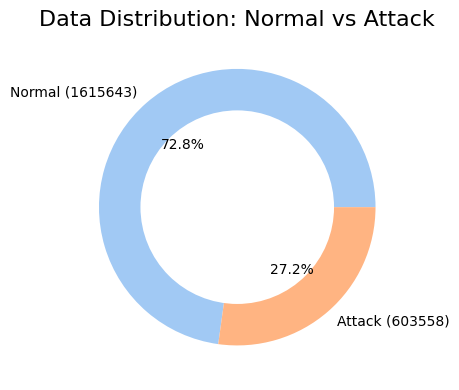

Execition time: 11491 ms


In [ ]:
start_time_pie = time_now()

rows = df_clean.groupBy("Binary_Label") \
               .count() \
               .orderBy("Binary_Label") \
               .collect()
counts = []
labels = []
for row in rows:
    counts.append(row['count'])
    if row['Binary_Label'] == 0:
        labels.append(f"Normal ({row['count']})")
    else:
        labels.append(f"Attack ({row['count']})")

colors = sns.color_palette('pastel')[0:2]
plt.figure(figsize=(6, 4))
plt.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
)

plt.title('Data Distribution: Normal vs Attack', fontsize=16)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.tight_layout()
plt.show()

end_time_pie = time_now()
print(f'Execition time: {calculate_elapsed_time(start_time_pie, end_time_pie)} ms')

As the visualization demonstrates, the dataset exhibits a significant class imbalance: 72.8% Normal vs 27.2% Attack.

 ### 2: Distribution of the Traffic

This analysis quantifies the volumetric distribution of network packets across different traffic classes. By aggregating traffic types, we aim to identify class imbalances and distinguish between high-volume volumetric attacks and low-volume (high-precision attacks).

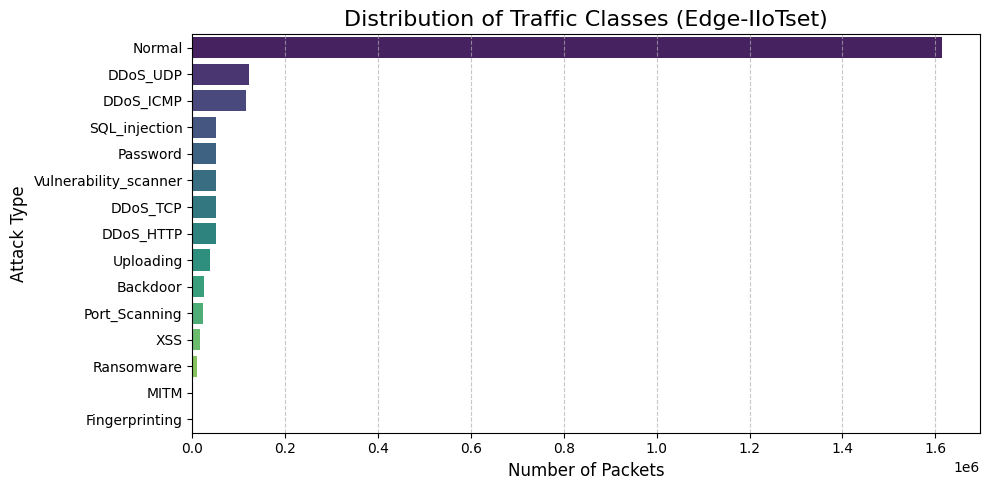

Execution time: 12231 ms


In [ ]:
start_time = time_now()
attack_stats = df_clean.groupBy("Attack_type") \
                       .count() \
                       .orderBy("count", ascending=False)

data_collected = attack_stats.collect()
y_vals = [row['Attack_type'] for row in data_collected]
x_vals = [row['count'] for row in data_collected]


plt.figure(figsize=(10, 5))
sns.barplot(
    x=x_vals,
    y=y_vals,
    hue=y_vals,
    legend=False,
    palette="viridis"
)

plt.title('Distribution of Traffic Classes (Edge-IIoTset)', fontsize=16)
plt.xlabel('Number of Packets', fontsize=12)
plt.ylabel('Attack Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
ending_time = time_now()
print(f'Execution time: {calculate_elapsed_time(start_time, ending_time)} ms')

As visualized legitimate traffic overwhelmingly dominates the dataset this confirms that the dataset is clearly imbalanced, Intuitively, volumetric attacks like DDoS generate the highest packet counts among malicious classes. In contrast, sophisticated vectors such as XSS and Ransomware exhibit very low packet volumes, as they rely on precision and stealth rather than network flooding.

### 3: Payload and Port Analysis

This analysis focuses on extracting distinct behavioral fingerprints for each attack type. Understanding these patterns allows us to transition from reactive analysis to proactive defense, evaluating the potential for introducing automated blocking rules within the network infrastructure (e.g Firewall).

In [ ]:
start_time_stats = time_now()

stats_df = df_clean.groupBy("Attack_type").agg(
    count("*").alias("Total_Packets"),
    avg("Unified_Payload").alias("Avg_Payload_Size"),
    stddev("Unified_Payload").alias("StdDev_Payload"),
    approx_count_distinct("tcp_srcport").alias("Unique_Src_Ports_Used")
)

stats_formatted = stats_df.select(
    col("Attack_type"),
    format_number("Total_Packets", 0).alias("Total_Pkts"),
    format_number("Avg_Payload_Size", 2).alias("Avg_Bytes"),
    format_number("StdDev_Payload", 2).alias("Volatility(StdDev)"),
    format_number("Unique_Src_Ports_Used", 0).alias("Src_Ports_Count")
).orderBy(col("Volatility(StdDev)").asc())

stats_formatted.show(20, truncate=False)

end_time_stats = time_now()
print(f'Execution time: {calculate_elapsed_time(start_time_stats, end_time_stats)} ms')

+---------------------+----------+---------+------------------+---------------+
|Attack_type          |Total_Pkts|Avg_Bytes|Volatility(StdDev)|Src_Ports_Count|
+---------------------+----------+---------+------------------+---------------+
|Port_Scanning        |22,564    |0.00     |0.00              |9,079          |
|DDoS_UDP             |121,568   |0.00     |0.00              |52,588         |
|Fingerprinting       |1,001     |0.00     |0.00              |135            |
|DDoS_ICMP            |116,436   |0.00     |0.00              |1              |
|DDoS_HTTP            |49,911    |43.40    |123.08            |10,604         |
|MITM                 |1,214     |4,892.41 |13,848.08         |1              |
|SQL_injection        |51,203    |76.26    |172.44            |4,593          |
|XSS                  |15,915    |63.57    |193.01            |1,041          |
|Ransomware           |10,925    |177.05   |223.29            |596            |
|Uploading            |37,634    |62.90 

The analysis identifies three principal behavioral signatures:

1.   Seeing the **volatility** we can observe that in some cases like **DDos UDP** and **Port Scanning** show zero volatility, indicating a mechanical generation that permit to distinguish them from a **Normal** communication

2. Observing the **Src_Ports_Count** we can see some outlier in **DDos UDP** and **DDos ICMP** this indicate that in DDos UDP there is use of botnets and DDos ICMP use a single-source script to create the attack

3. The table shows also an anomaly for **MITM** that shows an extreme payload size and variance, confirming the active interception and encapsulation of full data streams.


This analysis reveals some pattern in the attacks that can be used to define rules or alert to prevent the violation.

### Supervised Classification

After the previous analysis for each attack vector, we now aim to operationalize these insights. The objective is to develop a scalable classifier that can automatically identify and categorize malicious network traffic.

In [ ]:
start_time_ml = time_now()

assembler = VectorAssembler(inputCols=selected_features, outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withStd=True, withMean=True)
indexer = StringIndexer(inputCol="Attack_type", outputCol="label").fit(df_clean)

#define the model
lr = LogisticRegression(featuresCol="features_scaled", labelCol="label", family="multinomial", maxIter=100)

pipeline = Pipeline(stages=[indexer, assembler, scaler, lr])
train_data, test_data = df_clean.randomSplit([0.8, 0.2], seed=42) # split train 80% and test 20%

## training
model = pipeline.fit(train_data)
## make predictions
predictions = model.transform(test_data)
end_time_ml = time_now()
## perform evaluations
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
acc = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
prec_w = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
rec_w = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
f1_w = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print(f"Accuracy:  {acc:.4f}")
print(f"Precision (Weighted): {prec_w:.4f}")
print(f"Recall (Weighted):    {rec_w:.4f}")
print(f"F1 Score (Weighted):  {f1_w:.4f}")
print(f'Execution time: {calculate_elapsed_time(start_time_ml, end_time_ml)} ms')

Accuracy:  0.8068
Precision (Weighted): 0.6921
Recall (Weighted):    0.8068
F1 Score (Weighted):  0.7380
Execution time: 290208 ms


While the model secures a global Accuracy of 80.92%, this figure is biased by the dominance of the 'Normal' class. The true performance is better reflected by the Weighted F1-Score (74.34%). The 6% gap confirms that the model is robust in filtering legitimate traffic but struggles to maintain precision when classifying specific, low-volume threats.

These results serve as a starting point. Future iterations could enhance performance by introducing additional features to the training set and exploring non-linear models (such as Random Forest or Gradient Boosting) to better capture complex attack patterns.

## **P3**: Performance Evaluation

This section presents the performance analysis of the PySpark solution developed in P2. The dataset used have this specs:

*   **Name**: Edge-IIoTset
*   **Size**: 1.22 GB
*   **Columns**: 63
*   **Rows**: 2,219,201  


The application was executed in three different configurations to evaluate scalability and resource utilization:

1.  `local[1]`: Single-core execution.
2.   `local[*]`: Multi-core execution (using all available logical cores on the node).
3.  `Cluster (YARN)`: Distributed execution on the cluster.

The table below summarizes the execution time (in milliseconds) for each task.

| Task Name | Local [1] (ms) | Local [*] (ms) | Cluster (YARN) (ms)
| :--- | :--- | :--- | :--- |
| **Data Loading & Cleaning** | 12129.32 | 9163.92 | 14887.93 |
| **Data Distribution (Pie)** | 20041.46 | 7972.36 | 10787.40 |
| **Traffic Analysis (Bar)** | 20895.02 | 5937.36 | 10511.16 |
| **Payload & Port Analysis** | 26989.58 | 7461.84 | 10503.76 |
| **ML Pipeline** | (timeout reached) | 200582.32 | 194962.29 |
| **Total Execution Time** | **N/A** | **231117.80** | **241,652.54** |

---
### Performance Analysis
With this dataset, I explicitly encountered the limits of serial processing. In the `local[1]` configuration, the single processor was unable to handle the computational load of the ML task, resulting in a system timeout.

####Local Parallelism (`local[*]`) vs. `Distributed Cluster`

Comparing the multi-core local execution against the distributed cluster reveals an interesting trade-off regarding the "tipping point" of Big Data processing:

* **Total Time:** The `local[*]` configuration proved slightly faster (≈231s) than the Cluster (≈241s). This is primarily due to **network overhead**. In a distributed environment, the dataset must be distributed to worker nodes, and intermediate results (shuffling) must be transmitted over the network.  For a 1.22 GB dataset, this setup and transfer time slightly outweighs the raw computing power of the cluster.

* **Computing Power (ML Phase):** However, focusing solely on the most intensive task (Machine Learning Pipeline), the Cluster was faster (**194s**) compared to `local[*]` (200s). This confirms that the cluster provides superior raw processing power, but it pays a "tax" in data transfer latency.